In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import scanpy as sc
import anndata as ad
import skimage as skimage

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent.parent
input_file = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "bbn963sq7_filtered_feature_bc_matrix.h5"
)

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

output_dir = PROJECT_ROOT / "results" / "BBN963sq7"
output_dir.mkdir(parents=True, exist_ok=True)

UMAP_STYLE = {
    "legend_loc": "on data",
    "legend_fontsize": 9,
    "legend_fontweight": "semibold",
    "legend_fontoutline": 2,
    "size": 20,
    "alpha": 0.85,
    "marker": "o",
    "add_outline": True,
    "outline_width": (0.2, 0.03),
    "palette": "Set1",
    "ncols": 2,
    "wspace": 0.3,
}

In [3]:
adata_preprocessing = sc.read_10x_h5(input_file)
adata_preprocessing.var_names_make_unique()
adata_preprocessing.obs_names_make_unique()
adata_preprocessing.obs["sample"] = "BBN963sq7"

/Users/timothy/miniconda3/envs/python-311/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/timothy/miniconda3/envs/python-311/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
adata_preprocessing.shape

(5895, 33696)

Preprocessing

In [5]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata_preprocessing.var["mt"] = adata_preprocessing.var_names.str.startswith("mt-")
adata_preprocessing.var["ribo"] = adata_preprocessing.var_names.str.startswith(("Rps", "Rpl"))
adata_preprocessing.var["hb"] = adata_preprocessing.var_names.str.contains(r"^Hb[ab]", regex=True)

sc.pp.calculate_qc_metrics(adata_preprocessing, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

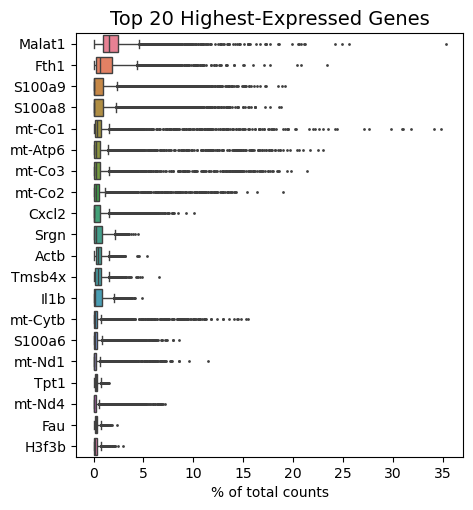

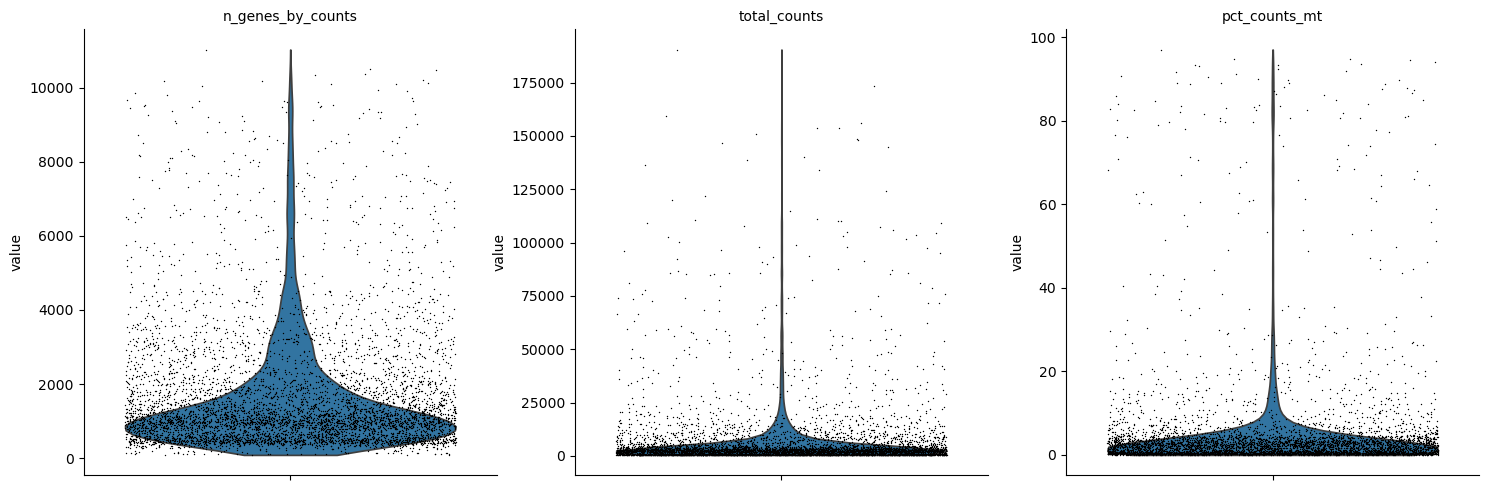

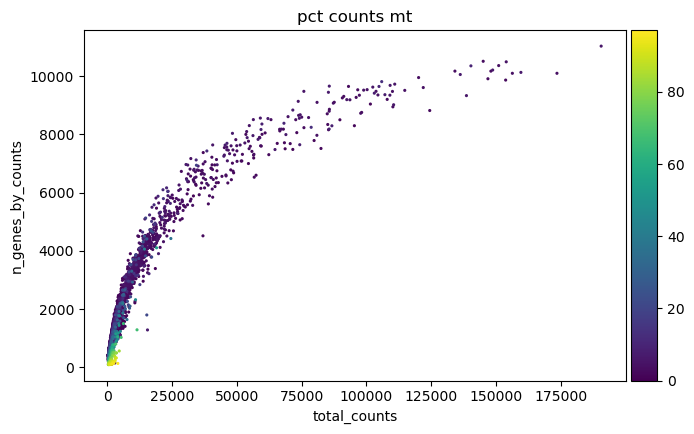

In [6]:
ax = sc.pl.highest_expr_genes(adata_preprocessing, n_top=20, show=False)
ax.set_title("Top 20 Highest-Expressed Genes", fontsize=14)

# Genes by counts
# Total Counts
# % Mitochondria
sc.pl.violin(
    adata_preprocessing,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

# 
sc.pl.scatter(adata_preprocessing, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [7]:
sc.pp.filter_cells(adata_preprocessing, min_genes=100) # filter out cells with fewer than 100 genes expressed
sc.pp.filter_genes(adata_preprocessing, min_cells=3) # filter out genes that are expressed in fewer than 3 cells
sc.pp.scrublet(adata_preprocessing) # scrublet to identify doublets
print(np.median(adata_preprocessing.obs["doublet_score"])) # print median doublet scores

adata_preprocessing = adata_preprocessing[adata_preprocessing.obs["doublet_score"] < 0.25] # filter out cells with high doublet scores
adata_preprocessing = adata_preprocessing[adata_preprocessing.obs["pct_counts_mt"] < 10].copy() # filter out cells with high mt gene expression (revisit, may be real biology)

0.03473302229134266


In [8]:
adata_preprocessing.shape

(5441, 21842)

Normalization

In [9]:
# Saving count data
adata_preprocessing.layers["counts"] = adata_preprocessing.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_preprocessing)
# Logarithmize the data
sc.pp.log1p(adata_preprocessing)

In [10]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, jaccard_score


# ---------------------------
# Configuration
# ---------------------------

HVG_VALUES = [1000, 2000, 3000, 5000]
FINAL_N_HVG = 2000

N_PCS = 50
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 0.5
RANDOM_STATE = 0


leukocyte_markers = {
    "Leukocytes": [
        "Ptprc",
        "Cd52",
        "Coro1a",
        "Lcp1",
        "Ptpn6",
        "Rac2",
        "Hcls1",
    ]
}

In [11]:
# Select leukocyte genes
leukocyte_genes = []
for gene in leukocyte_markers["Leukocytes"]: 
    if gene in adata_preprocessing.var_names:
        leukocyte_genes.append(gene)

# check if enough leukocyte genes were found in the dataset
if len(leukocyte_genes) < 3:
    raise ValueError(
        f"Only {len(leukocyte_genes)} leukocyte markers were found: "
        f"{leukocyte_genes}"
    )

print(
    f"Using {len(leukocyte_genes)} leukocyte markers:",
    leukocyte_genes,
)

# calculates a leukocyte marker-expression score for every cell
# basically like:
# leukocyte score = average expression of leukocyte marker genes − average expression of matched control genes
sc.tl.score_genes(
    adata_preprocessing,
    gene_list=leukocyte_genes,
    score_name="leukocyte_score",
    use_raw=False,
    random_state=RANDOM_STATE,
)

Using 7 leukocyte markers: ['Ptprc', 'Cd52', 'Coro1a', 'Lcp1', 'Ptpn6', 'Rac2', 'Hcls1']


GMM component means: [-0.27894902  0.34953808]
leukocyte_reference
Leukocyte        0.632604
Non-leukocyte    0.367396
Name: proportion, dtype: float64


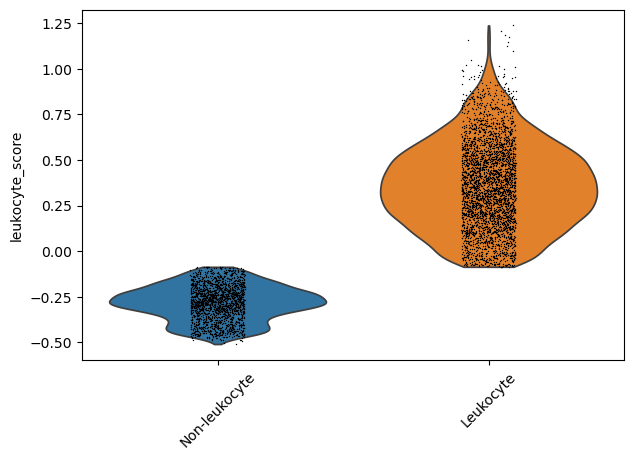

In [12]:
scores = (
    adata_preprocessing.obs["leukocyte_score"]
    .to_numpy()
    .reshape(-1, 1)
)

gmm = GaussianMixture(
    n_components=2,
    random_state=RANDOM_STATE,
).fit(scores)

components = gmm.predict(scores)

# The component with the higher score is called leukocytic
leukocyte_component = np.argmax(gmm.means_.ravel())

reference_bool = components == leukocyte_component

# Keep a Boolean column for calculations
adata_preprocessing.obs["leukocyte_reference_bool"] = reference_bool

# Keep a separate categorical column for plotting
adata_preprocessing.obs["leukocyte_reference"] = pd.Categorical(
    np.where(
        reference_bool,
        "Leukocyte",
        "Non-leukocyte",
    ),
    categories=["Non-leukocyte", "Leukocyte"],
)

print("GMM component means:", gmm.means_.ravel())

print(
    adata_preprocessing.obs["leukocyte_reference"]
    .value_counts(normalize=True)
)

sc.pl.violin(
    adata_preprocessing,
    keys="leukocyte_score",
    groupby="leukocyte_reference",
    rotation=45,
)

In [13]:
binary_assignments = {}
hvg_results = []

for n_hvg in HVG_VALUES:
    print(f"Testing {n_hvg} HVGs")

    ad_test = adata_preprocessing.copy()

    # Select HVGs without removing other genes
    sc.pp.highly_variable_genes(
        ad_test,
        flavor="seurat",
        n_top_genes=n_hvg,
        subset=False,
    )

    sc.pp.pca(
        ad_test,
        n_comps=50,
        mask_var="highly_variable",
        random_state=RANDOM_STATE,
    )

    sc.pp.neighbors(
        ad_test,
        n_neighbors=N_NEIGHBORS,
        n_pcs=N_PCS,
        random_state=RANDOM_STATE,
    )

    cluster_key = f"leiden_{n_hvg}"

    sc.tl.leiden(
        ad_test,
        resolution=LEIDEN_RESOLUTION,
        key_added=cluster_key,
        random_state=RANDOM_STATE,
    )

    reference = (
        ad_test.obs["leukocyte_reference_bool"]
        .astype(bool)
    )

    clusters = ad_test.obs[cluster_key].astype(str)

    # Fraction of reference leukocytes in each cluster
    leukocyte_fraction = reference.groupby(clusters).mean()

    # Call a cluster leukocytic when at least half its cells
    # are reference leukocytes
    predicted = (
        clusters.map(leukocyte_fraction.ge(0.5))
        .astype(bool)
    )

    binary_assignments[n_hvg] = predicted.copy()

    mixed_clusters = (
        leukocyte_fraction.between(
            0.20,
            0.80,
            inclusive="neither",
        )
    ).sum()

    hvg_results.append({
        "n_hvg": n_hvg,
        "n_clusters": clusters.nunique(),
        "jaccard_vs_reference": jaccard_score(
            reference,
            predicted,
        ),
        "ari_vs_reference": adjusted_rand_score(
            reference,
            predicted,
        ),
        "discordant_fraction": np.mean(
            reference.to_numpy() != predicted.to_numpy()
        ),
        "mixed_clusters": mixed_clusters,
    })


hvg_results = pd.DataFrame(hvg_results)

hvg_results

Testing 1000 HVGs


/Users/timothy/miniconda3/envs/python-311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gg/932gdyqn2_q_br7zccl_28y80000gn/T/ipykernel_10913/1325651582.py:33: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


Testing 2000 HVGs
Testing 3000 HVGs
Testing 5000 HVGs


,n_hvg,n_clusters,jaccard_vs_reference,ari_vs_reference,discordant_fraction,mixed_clusters
0,1000,10,0.901591,0.747728,0.067083,0
1,2000,11,0.902077,0.749020,0.066716,0
2,3000,11,0.902294,0.749675,0.066532,0
3,5000,13,0.902808,0.750960,0.066164,1


In [14]:
# Select the final HVG set
sc.pp.highly_variable_genes(
    adata_preprocessing,
    flavor="seurat",
    n_top_genes=FINAL_N_HVG,
    subset=False,
)

# PCA using only the selected HVGs
sc.pp.pca(
    adata_preprocessing,
    n_comps=50,
    mask_var="highly_variable",
    random_state=RANDOM_STATE,
)

# Neighbor graph
sc.pp.neighbors(
    adata_preprocessing,
    n_neighbors=N_NEIGHBORS,
    n_pcs=N_PCS,
    random_state=RANDOM_STATE,
)

# UMAP
sc.tl.umap(
    adata_preprocessing,
    random_state=RANDOM_STATE,
)

# Final Leiden clustering
sc.tl.leiden(
    adata_preprocessing,
    resolution=LEIDEN_RESOLUTION,
    key_added="leiden",
    random_state=RANDOM_STATE,
)

In [15]:
reference = (
    adata_preprocessing.obs["leukocyte_reference_bool"]
    .astype(bool)
)

clusters = adata_preprocessing.obs["leiden"].astype(str)

cluster_leukocyte_fraction = reference.groupby(clusters).mean()

cluster_prediction_bool = (
    clusters.map(cluster_leukocyte_fraction.ge(0.5))
    .astype(bool)
)

adata_preprocessing.obs["leukocyte_cluster_call"] = pd.Categorical(
    np.where(
        cluster_prediction_bool,
        "Leukocyte",
        "Non-leukocyte",
    ),
    categories=["Non-leukocyte", "Leukocyte"],
)

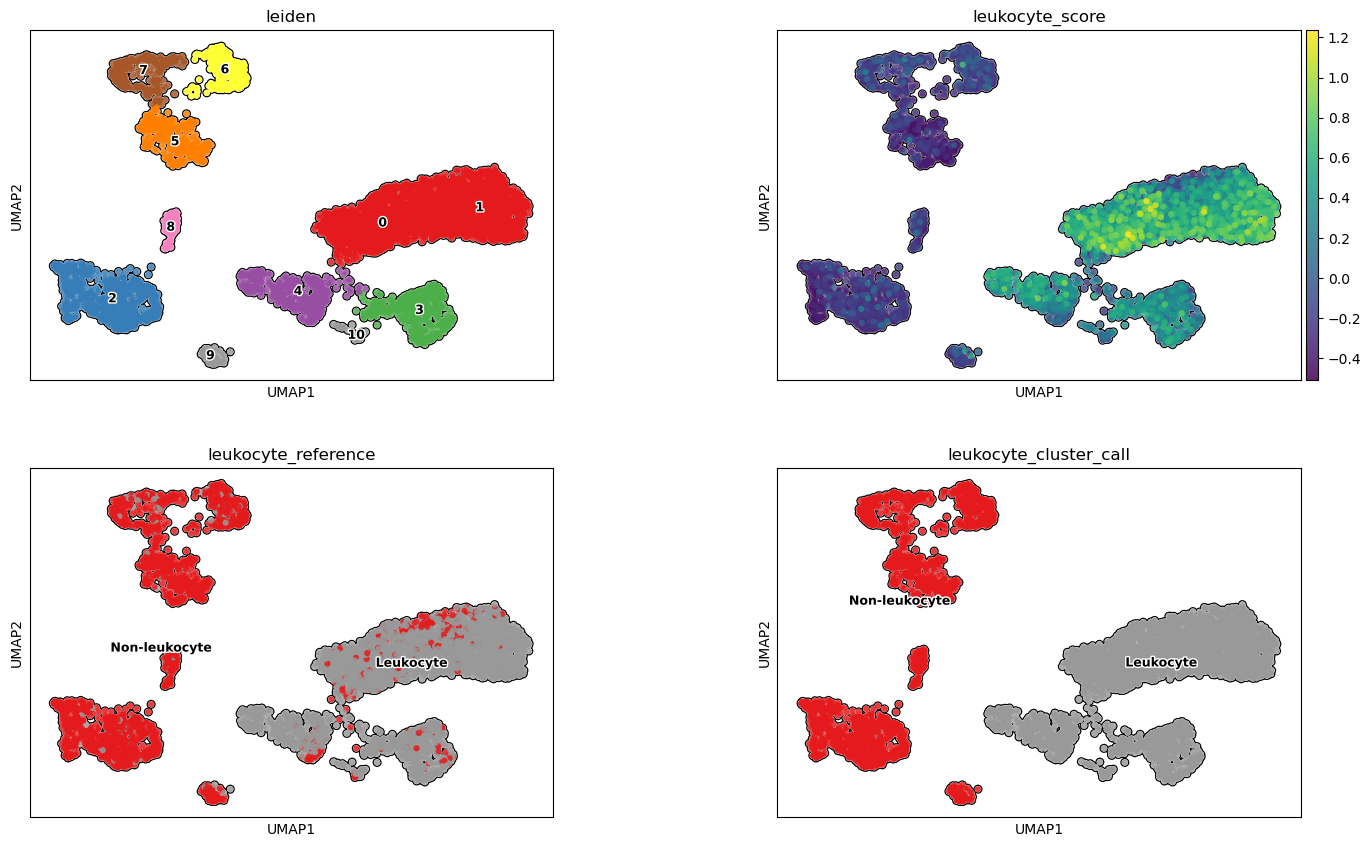

In [16]:
sc.pl.umap(
    adata_preprocessing,
    color=[
        "leiden",
        "leukocyte_score",
        "leukocyte_reference",
        "leukocyte_cluster_call",
    ],
    **UMAP_STYLE
)

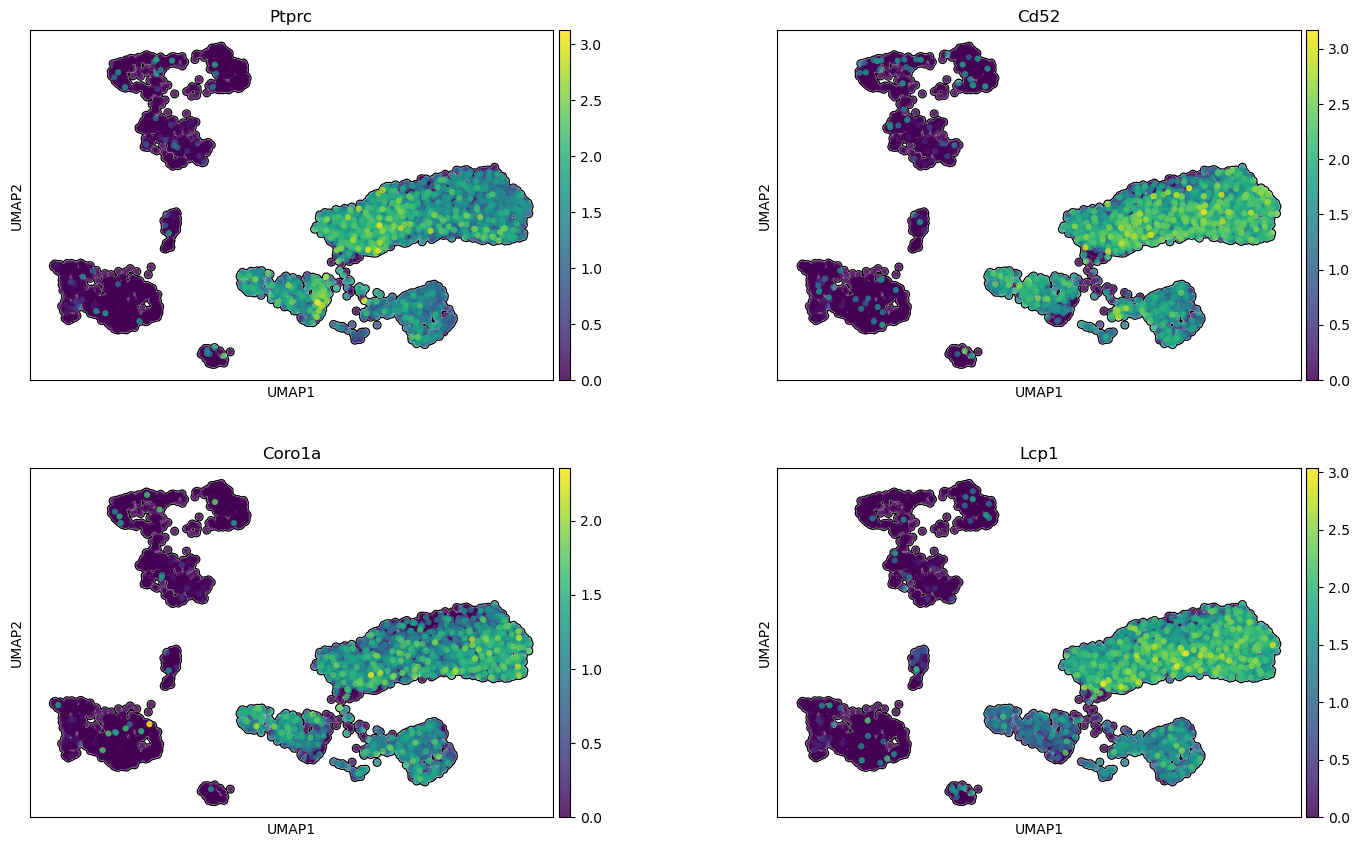

In [17]:
genes_to_plot = [
    gene
    for gene in ["Ptprc", "Cd52", "Coro1a", "Lcp1"]
    if gene in adata_preprocessing.var_names
]

sc.pl.umap(
    adata_preprocessing,
    color=genes_to_plot,
    cmap="viridis",
    **UMAP_STYLE
)

In [18]:
cluster_summary = (
    adata_preprocessing.obs
    .assign(
        reference_leukocyte=reference,
        cluster_leukocyte=cluster_prediction_bool,
        discordant=reference != cluster_prediction_bool,
    )
    .groupby("leiden", observed=True)
    .agg(
        n_cells=("discordant", "size"),
        leukocyte_fraction=("reference_leukocyte", "mean"),
        discordant_fraction=("discordant", "mean"),
        mean_leukocyte_score=("leukocyte_score", "mean"),
    )
    .sort_values(
        "leukocyte_fraction",
        ascending=False,
    )
)

cluster_summary

,n_cells,leukocyte_fraction,discordant_fraction,mean_leukocyte_score
leiden,,,,
3,475,0.943158,0.056842,0.224586
1,1201,0.938385,0.061615,0.364965
0,1485,0.918519,0.081481,0.358708
4,411,0.905109,0.094891,0.251260
10,37,0.891892,0.108108,0.085202
7,254,0.102362,0.102362,-0.217666
9,87,0.091954,0.091954,-0.231203
6,270,0.088889,0.088889,-0.195188
8,94,0.053191,0.053191,-0.283895


# At this point, save the processed adata object separately so any further analysis can be done without having to rerun QC

In [19]:
adata_preprocessing.write_h5ad(PROJECT_ROOT / "data" / "processed" / "bbn963sq7_processed_unlabeled.h5ad")

# Unlabeled means the cell types are UNLABELED, meaning that the cell types have not been assigned yet
# The data has been processed and filtered, but the specific cell type annotations are not included in this file
adata_processed = sc.read_h5ad(PROJECT_ROOT/ "data" / "processed" / "bbn963sq7_processed_unlabeled.h5ad")

## Now try to filter to leukocytes / nonleukocytes

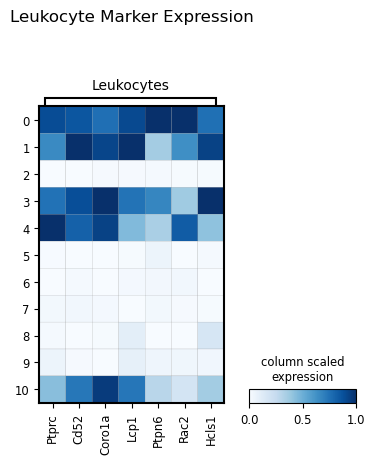

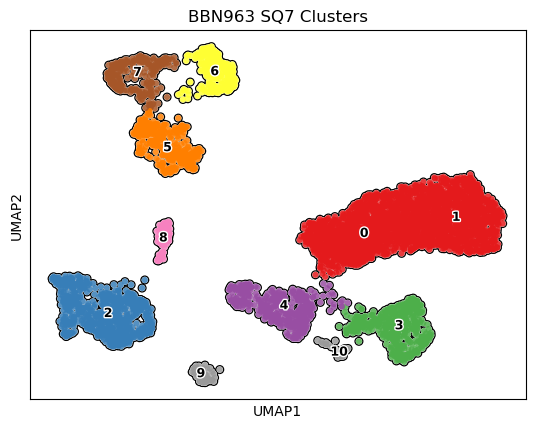

In [20]:
mp = sc.pl.matrixplot(
    adata_processed,
    leukocyte_markers,
    "leiden",
    dendrogram=False,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
    title="Leukocyte Marker Expression",
    var_group_rotation=0,
    return_fig=True,
)

mp.savefig(
    output_dir / "BBN963_SQ7_leukocyte_matrixplot.png",
    dpi=600,
    bbox_inches="tight",
)

umap_plot = sc.pl.umap(
    adata_processed,
    color="leiden",
    title="BBN963 SQ7 Clusters",
    return_fig=True,
    show=False,
    **UMAP_STYLE,
)

umap_plot.savefig(
    output_dir / "BBN963_SQ7_leiden_umap.png",
    dpi=600,
    bbox_inches="tight",
)

In [24]:
adata_leukocytes = adata_processed[
    adata_processed.obs["leiden"].isin(["0", "1", "3", "4", "10"])
].copy()

adata_leukocytes.write_h5ad(PROJECT_ROOT / "data" / "processed" / "bbn963sq7_processed_leukocytes.h5ad")

## Looking at markers for different immune cell types

In [25]:
broad_celltype_markers = {
    "tumor_epithelial": [
        "Epcam", "Krt5", "Krt6a", "Krt14",
        "Krt17", "Cd44", "Cdh3", "Cldn4"
    ],

    "myeloid_immune": [
        "Lyz2", "Aif1", "Csf1r", "Adgre1",
        "C1qa", "C1qb", "C1qc", "Tyrobp",
        "Fcgr3", "Trem2"
    ],

    "lymphoid_immune": [
        "Cd3d", "Cd3e", "Trac", "Lck",
        "Cd2", "Nkg7", "Prf1", "Gzmb",
        "Ms4a1", "Cd79a"
    ],

    "stromal_vascular": [
        "Col1a1", "Col1a2", "Dcn", "Lum",
        "Pdgfra", "Acta2", "Rgs5",
        "Pecam1", "Cdh5", "Kdr"
    ],
}

TUMOR_EPITHELIAL:


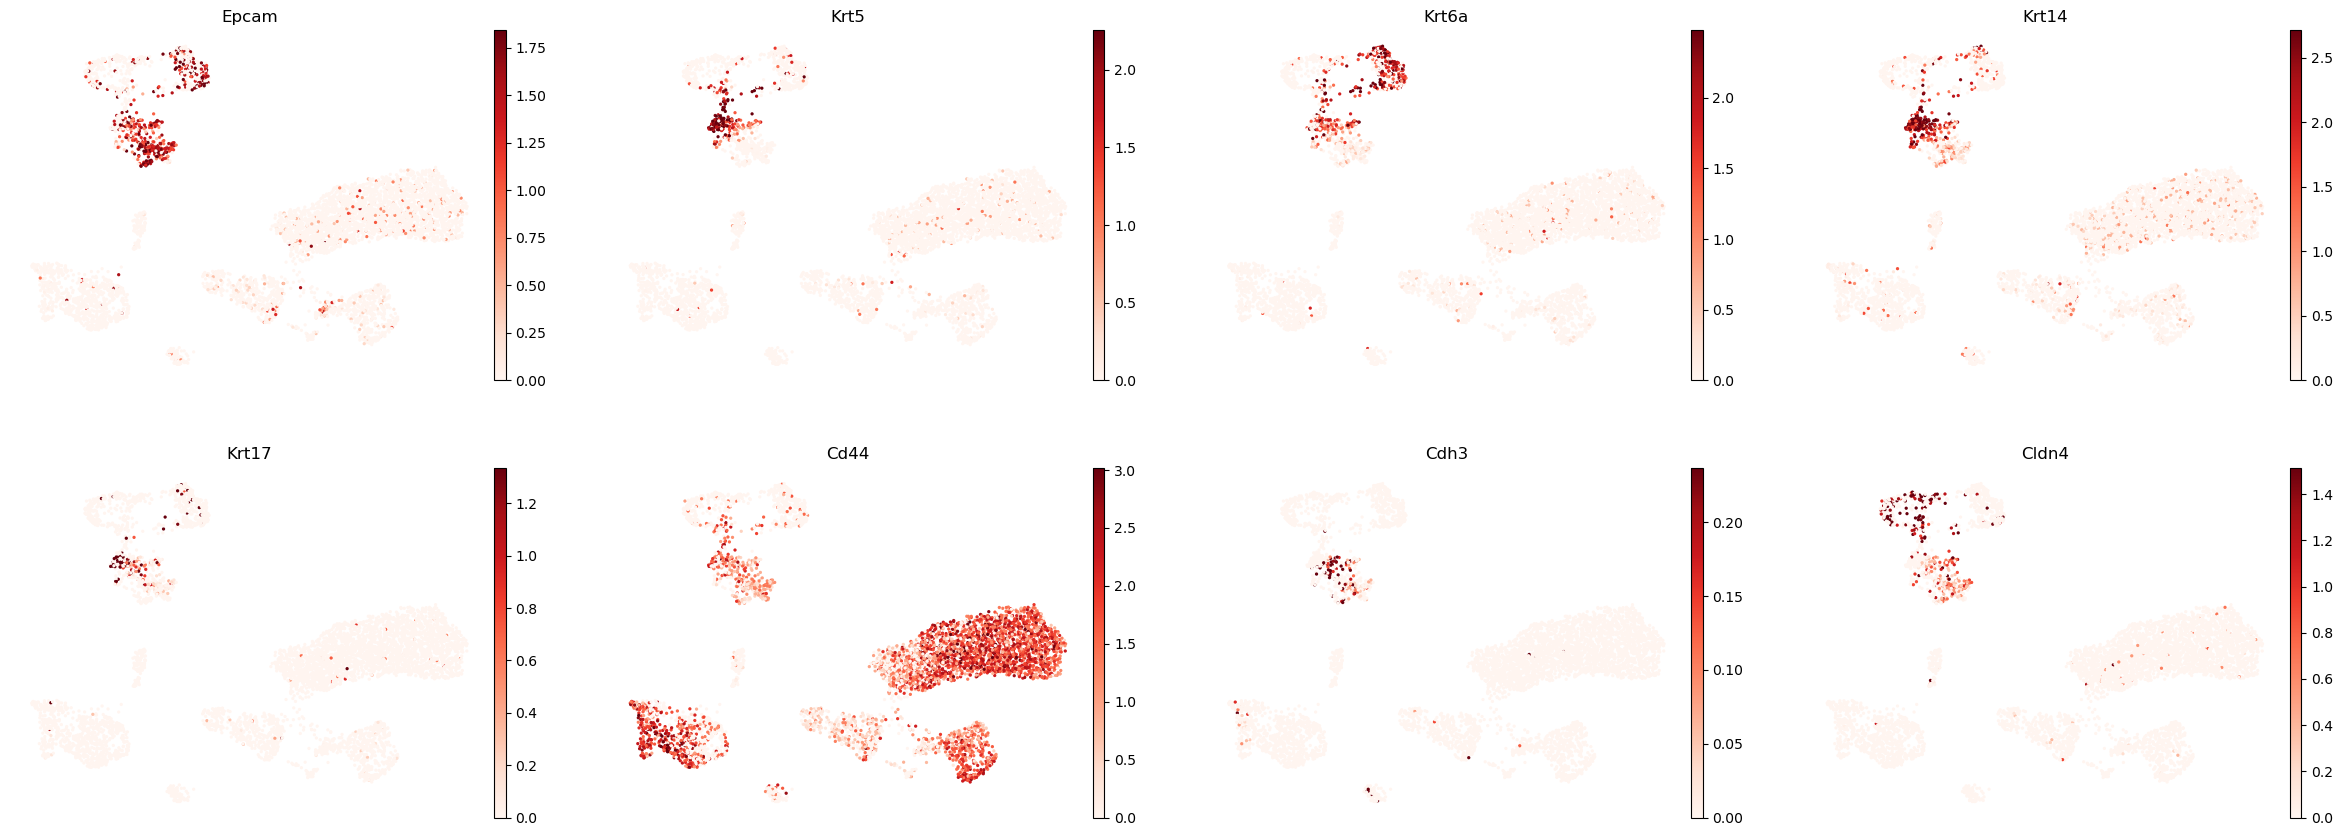





MYELOID_IMMUNE:


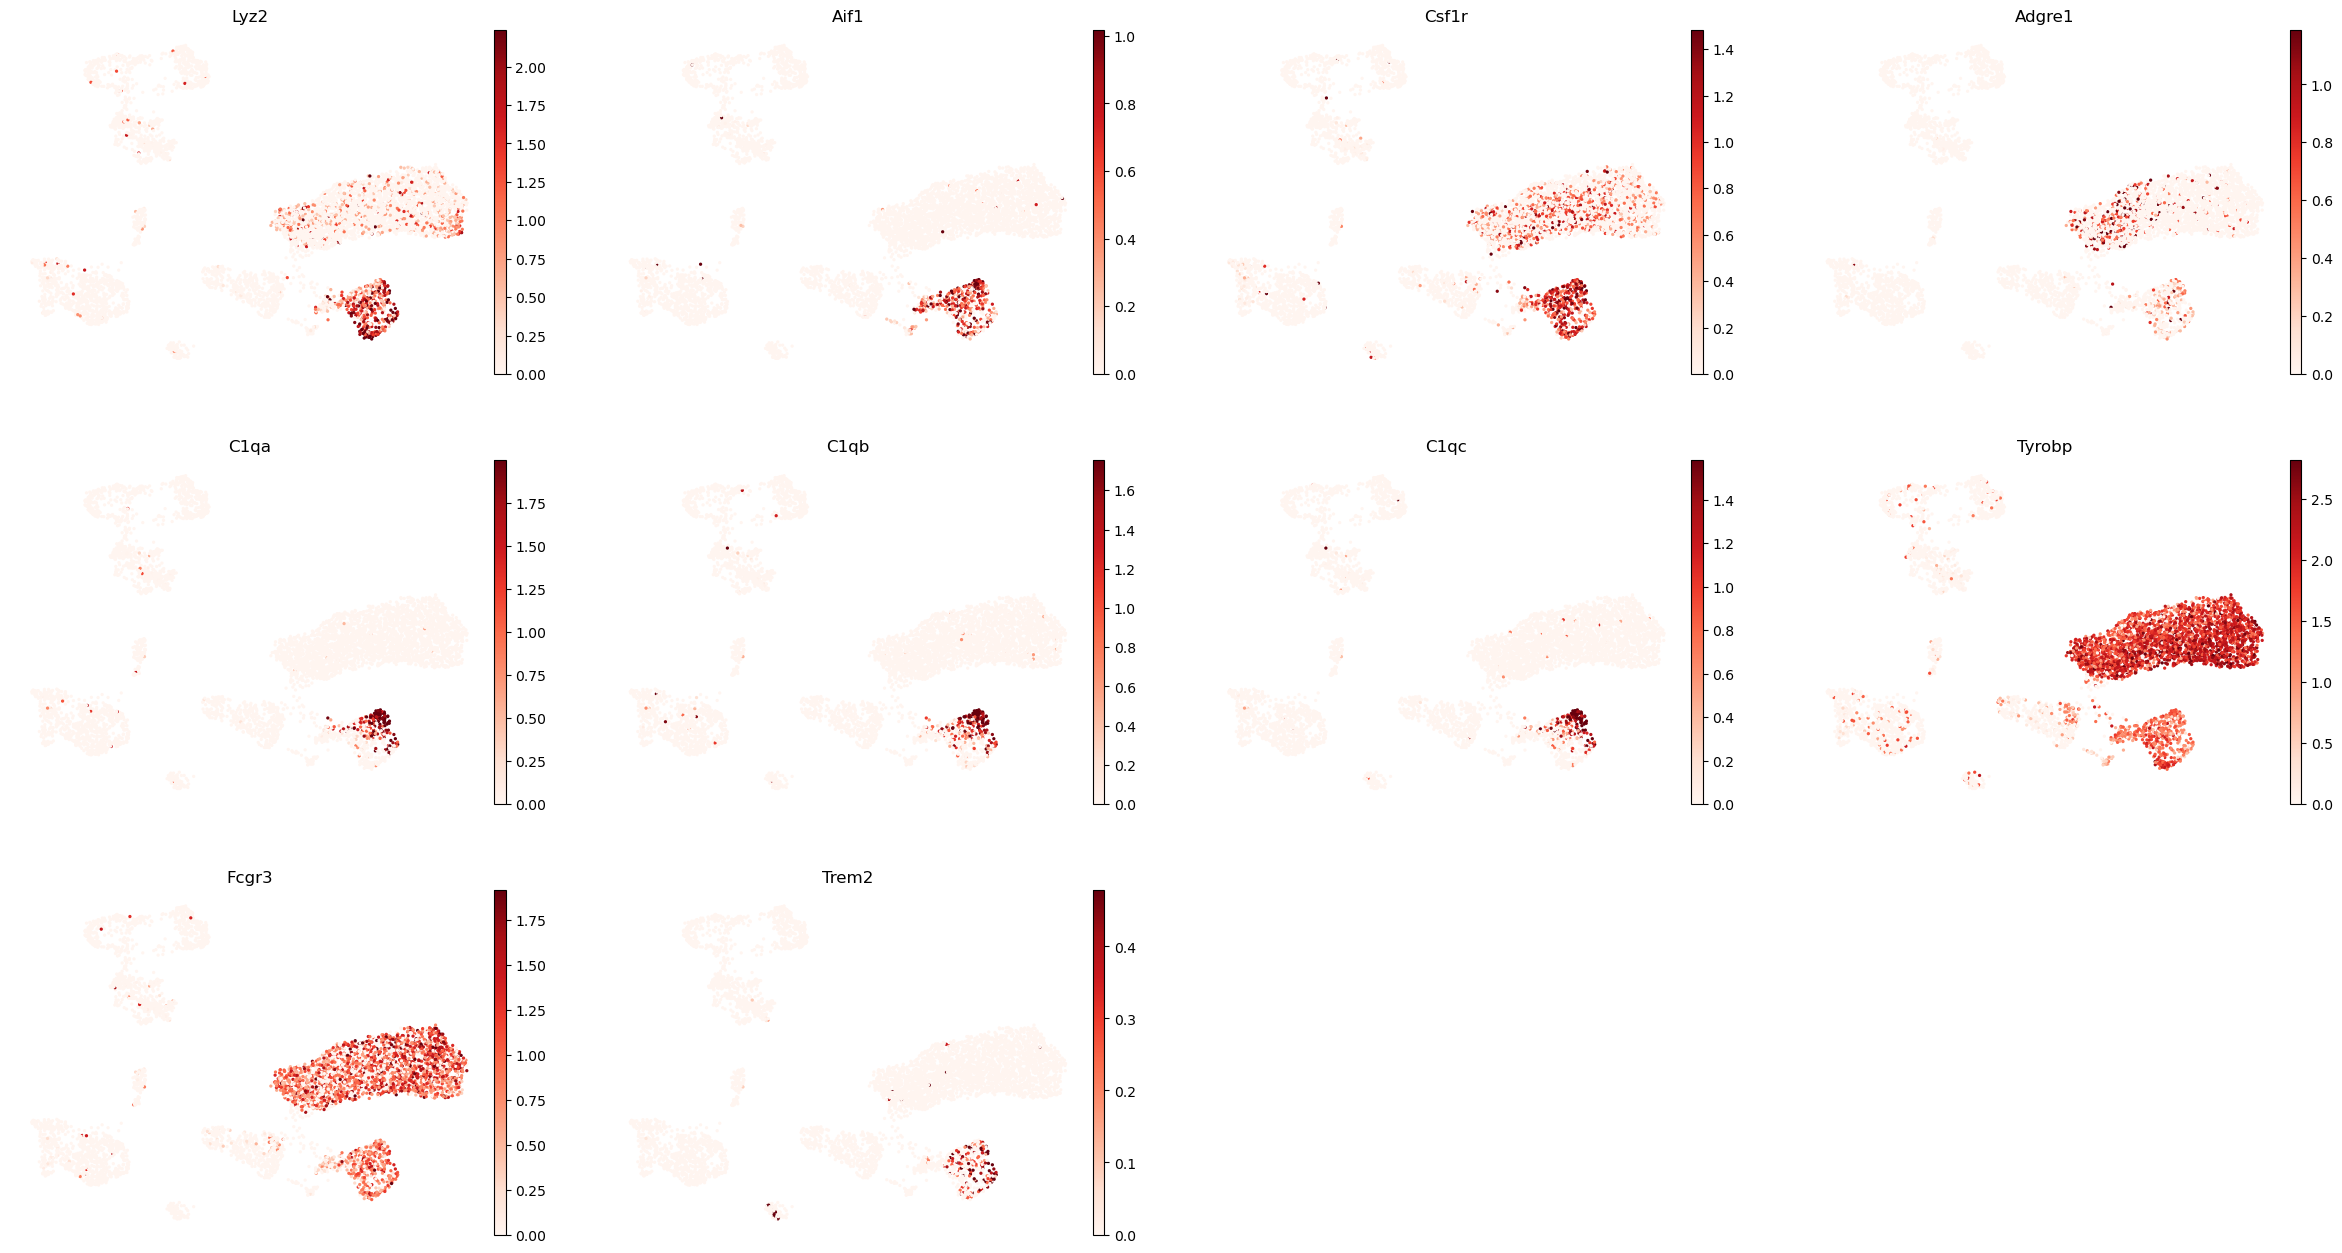





LYMPHOID_IMMUNE:


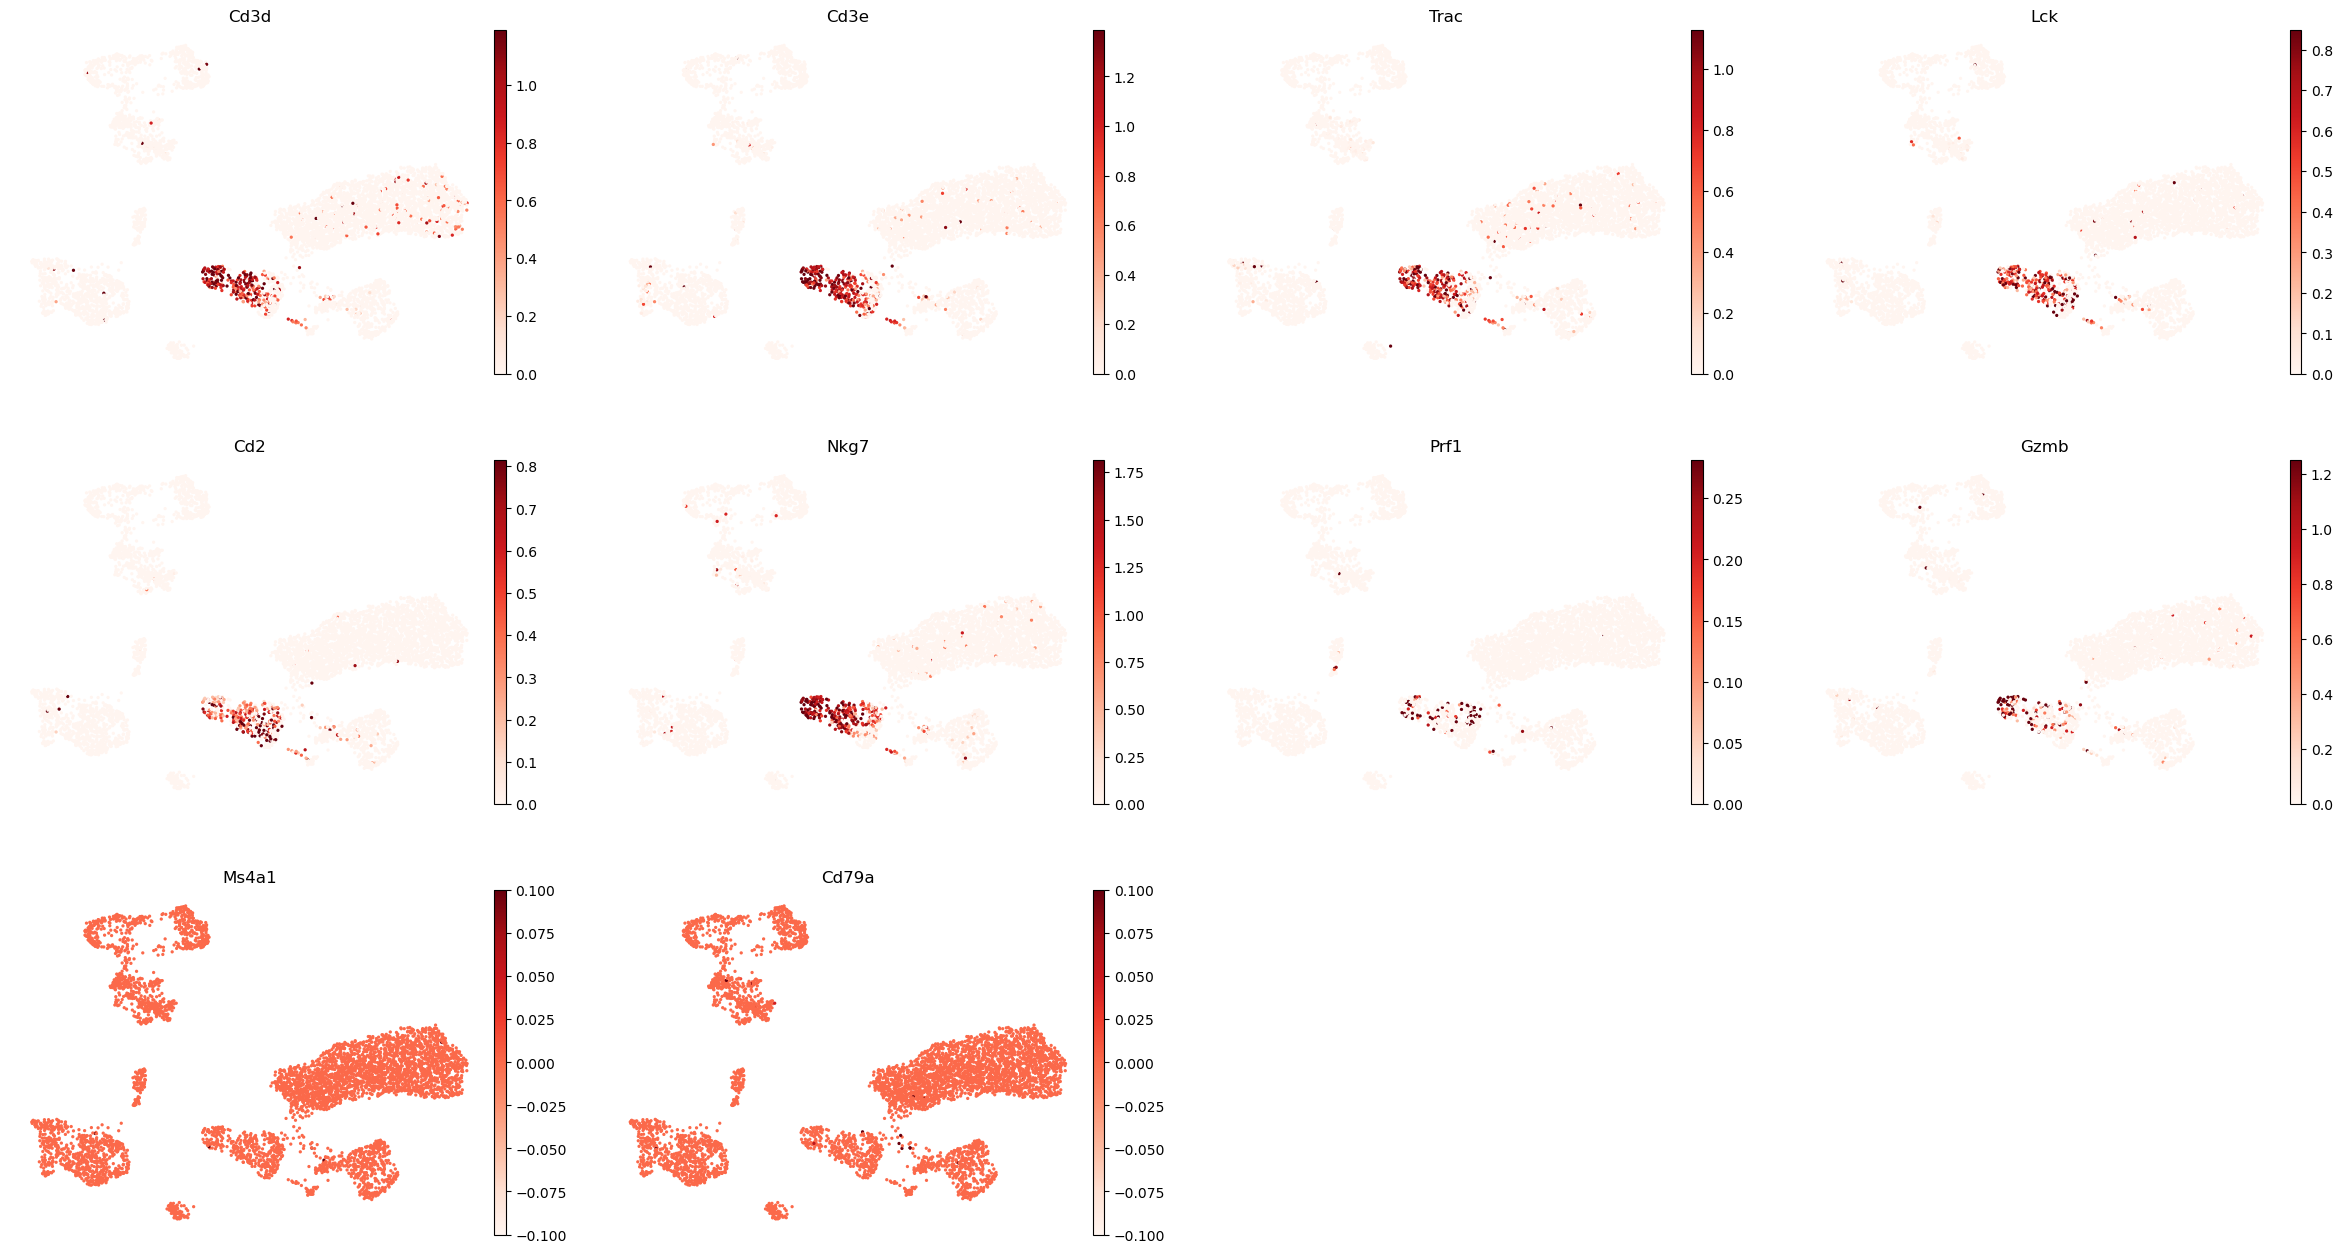





STROMAL_VASCULAR:


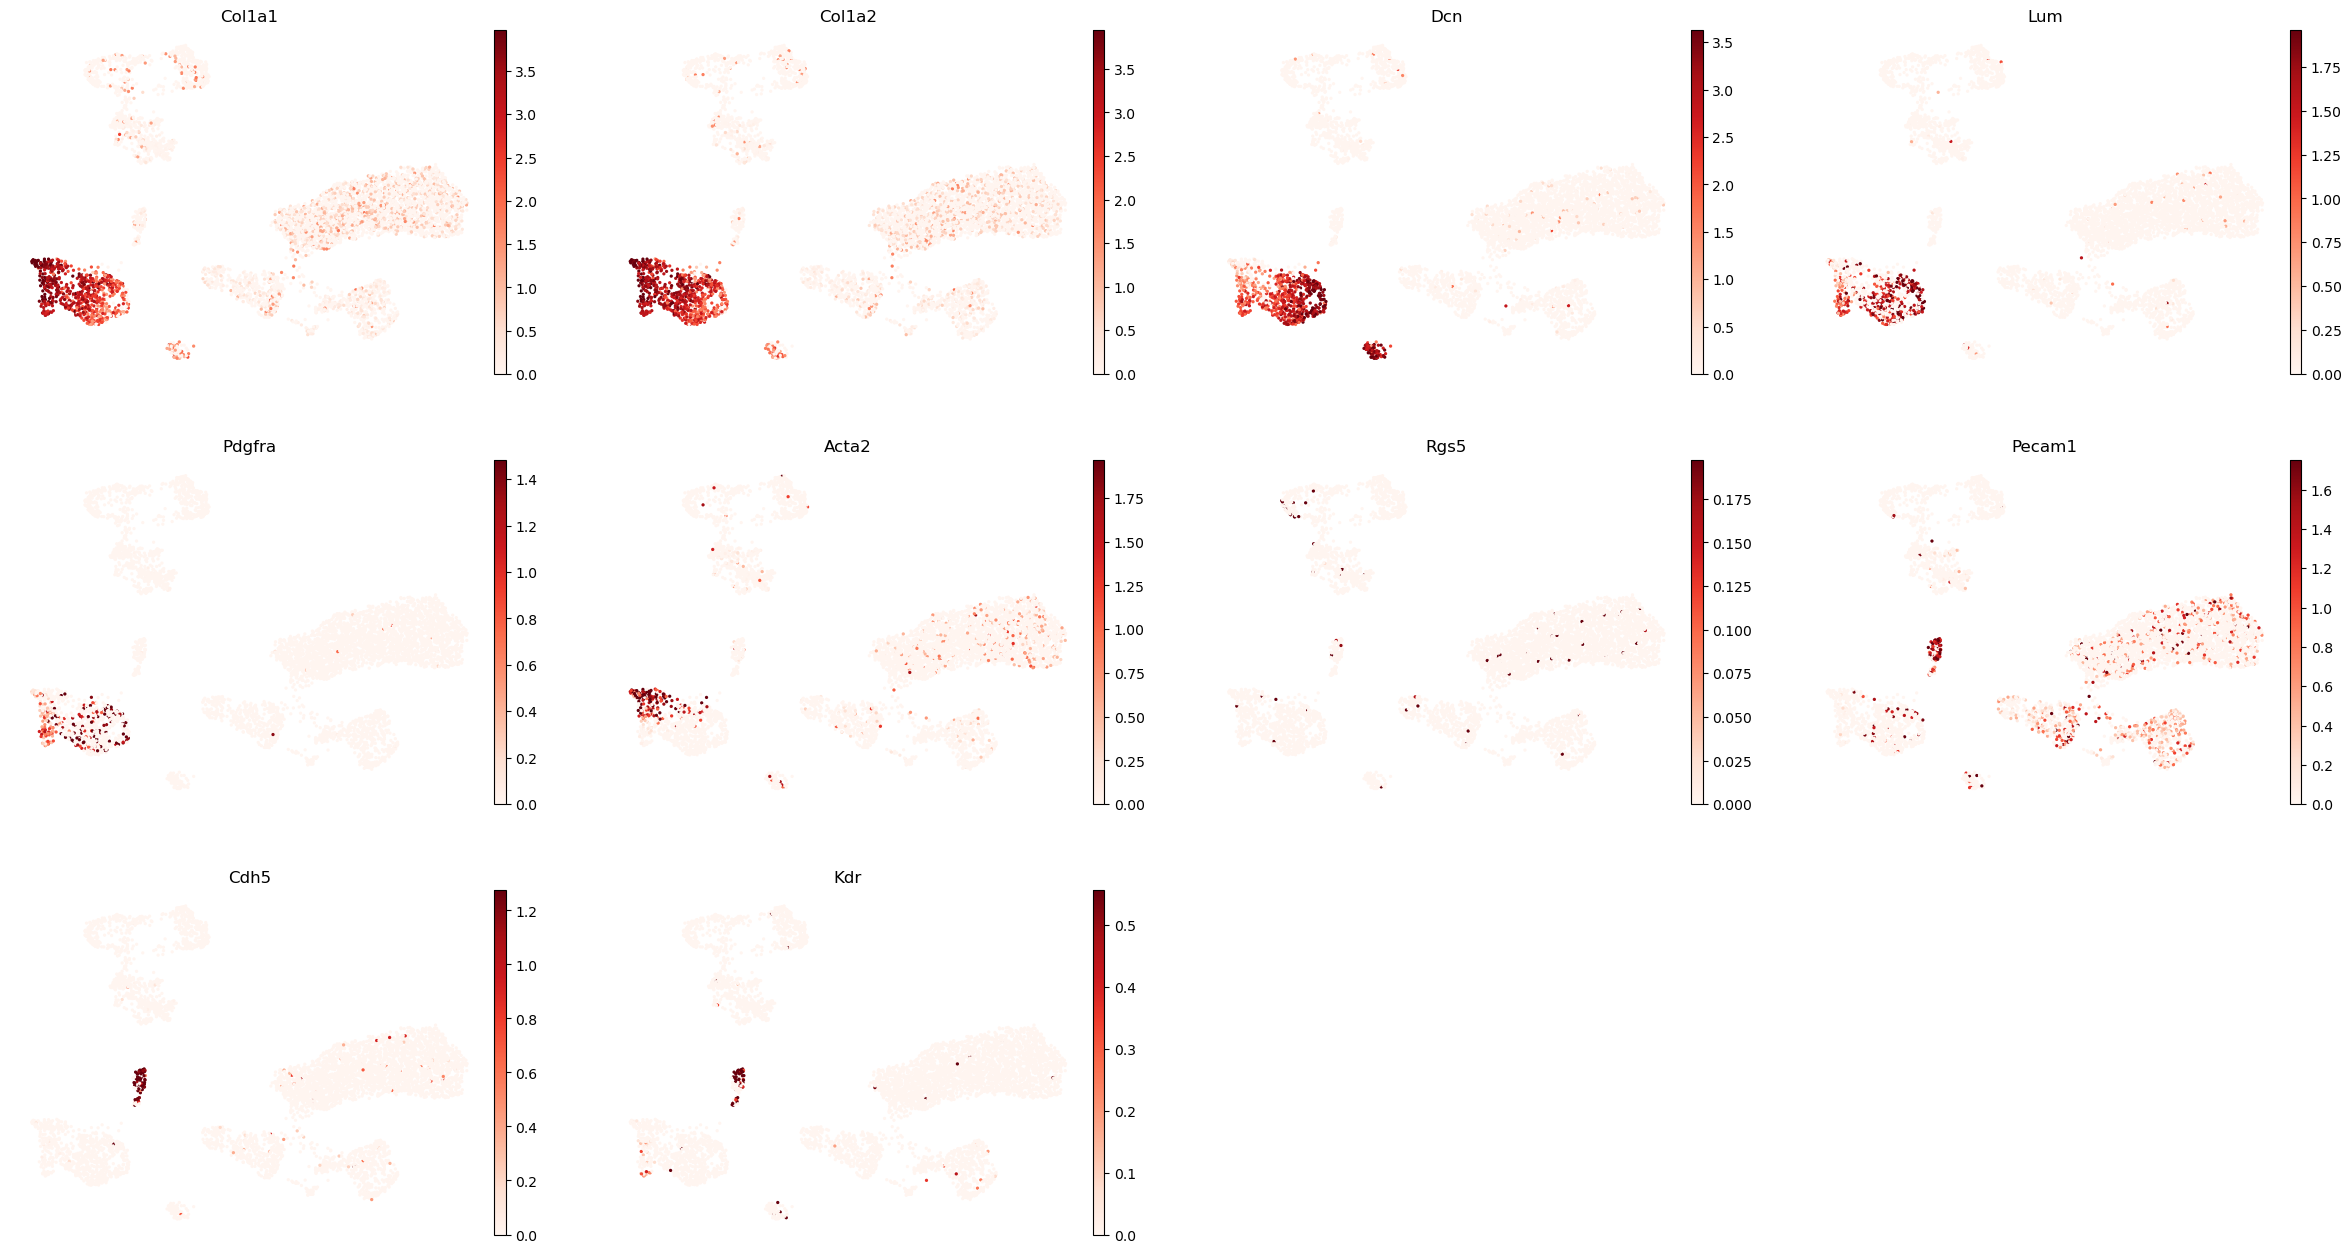

In [26]:
for ct, markers in broad_celltype_markers.items():
    markers_found = []
    for marker in markers:
        if marker in adata_processed.var.index:
            markers_found.append(marker)
    broad_celltype_markers[ct] = markers_found

cluster_4_names = list(broad_celltype_markers.keys())
for ct in cluster_4_names:
    print(f"{ct.upper()}:")  # print cell subtype name
    sc.pl.umap(
        adata_processed,
        color=broad_celltype_markers[ct],
        vmin=0,
        vmax="p99",  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
        sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
        frameon=False,
        cmap="Reds",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
    )
    print("\n\n\n")  # print white space for legibility